In [91]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import os
import operator

load_dotenv()

True

In [92]:
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
GROQ_MODEL=os.getenv("GROQ_MODEL")

In [93]:
generator_llm = ChatGroq(model=GROQ_MODEL, api_key=GROQ_API_KEY)
evaluation_llm = ChatGroq(model=GROQ_MODEL, api_key=GROQ_API_KEY)
optimizer_llm = ChatGroq(model=GROQ_MODEL, api_key=GROQ_API_KEY)

In [94]:
# state

class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved", "need_improvement"]
    feedback: str
    iteration: int
    max_iteration: int
    
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [95]:
class TweetEvaluationSchema(BaseModel):
    evaluation: Literal["approved", "need_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="Feedback for the tweet.")

In [96]:
structured_evaluater_llm = evaluation_llm.with_structured_output(TweetEvaluationSchema)

In [97]:
def generate_tweet(state: TweetState):
    topic = state["topic"]
    iteration = state["iteration"]
    
    # prompt
    message = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""Write a short, original, and hilarious tweet on the topic: "{topic}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
    ]
    
    # send to generator llm
    response = generator_llm.invoke(message).content
    
    # return response
    return {"tweet": response, "tweet_history": [response]}

In [98]:
def evaluate_tweet(state: TweetState):
    tweet = state["tweet"]
    
    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
    Evaluate the following tweet:

    Use the criteria below to evaluate the tweet:

    1. Originality – Is this fresh, or have you seen it a hundred times before?  
    2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
    3. Punchiness – Is it short, sharp, and scroll-stopping?  
    4. Virality Potential – Would people retweet or share it?  
    5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

    Auto-reject if:
    - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
    - It exceeds 280 characters
    - It reads like a traditional setup-punchline joke
    - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

    ### Respond ONLY in structured format:
    - evaluation: "approved" or "needs_improvement"  
    - feedback: One paragraph explaining the strengths and weaknesses 
    """)
    ]
    
    response = structured_evaluater_llm.invoke(messages)
    
    return {"evaluation": response.evaluation, "feedback": response.feedback, "feedback_history": [response.feedback]}

In [99]:
def optimize_tweet(state: TweetState):
    topic = state["topic"]
    tweet = state['tweet']
    feedback = state['feedback']
    iteration = state["iteration"]
    
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        "{feedback}"

        Topic: "{topic}"
        Original Tweet:
        {tweet}

        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
    ]
    
    response = optimizer_llm.invoke(messages).content
    iteration += 1
    
    return {"tweet": response, "iteration": iteration, "tweet_history": [response]}

In [100]:
def route_evaluation(state: TweetState):
    if state["evaluation"] == "approved" or state["iteration"] >= state["max_iteration"]:
        return "approved"
    else:
        return "need_improvement"

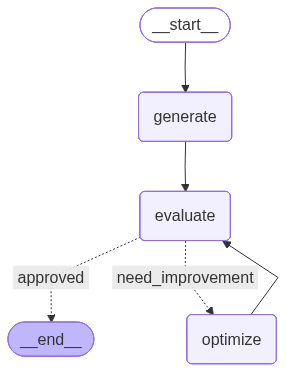

In [101]:
graph = StateGraph(TweetState)

graph.add_node("generate", generate_tweet)
graph.add_node("evaluate", evaluate_tweet)
graph.add_node("optimize", optimize_tweet)

graph.add_edge(START, "generate")
graph.add_edge("generate", "evaluate")

graph.add_conditional_edges("evaluate", route_evaluation, {"approved": END, "need_improvement": "optimize"})
graph.add_edge("optimize", "evaluate")

workflow = graph.compile()

workflow


In [102]:
initial_state = {
    "topic": "Breakup",
    "iteration": 1,
    "max_iteration": 5
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'topic': 'Breakup', 'tweet': "Now I'm the CEO of my couch, Netflix is my 401k, and cereal is a food group. Winning at breakup life #BreakupPerks", 'evaluation': 'need_improvement', 'feedback': "The tweet does not provide enough information to be evaluated based on the given criteria. However, I can provide general feedback on how to improve a tweet. To increase originality, try to come up with unique and fresh content that hasn't been seen before. For humor, ensure the tweet genuinely makes the reader smile or laugh. For punchiness, keep the tweet short and sharp. For virality potential, create content that people would want to retweet or share. Lastly, ensure the tweet is well-formed, under 280 characters, and doesn't follow a traditional setup-punchline joke format. Avoid using question-answer formats, generic lines, and make sure the tweet is engaging and scroll-stopping.", 'iteration': 5, 'max_iteration': 5, 'tweet_history': ["Just realized I'm single again. On the bright side, I 